# Negative binomial DE with quasi-likelihood dispersion shrinkage

`delnx` implements GPU-accelerated negative binomial GLMs following the [glmGamPoi](https://bioconductor.org/packages/release/bioc/html/glmGamPoi.html) approach with quasi-likelihood dispersion shrinkage for differential expression analysis. The two-step workflow (`nb_fit` + `nb_test`) separates model fitting from hypothesis testing, allowing you to reuse a single fit across multiple contrasts. Here's a quick example:

In [1]:
import delnx as dx
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

# Load example pseudobulk data
adata = sc.read_h5ad("data/GLI3_KO_45d_pseudobulk.h5ad")
adata.obs["GLI3_KO"] = adata.obs["GLI3_KO"].astype(str)  # Ensure string type for design matrix

print(adata)

AnnData object with n_obs × n_vars = 28 × 16199
    obs: 'psbulk_replicate', 'cell_type', 'organoid', 'GLI3_KO', 'psbulk_cells', 'psbulk_counts', 'size_factor'
    var: 'dispersion', 'dispersion_deseq', 'dispersion_mle', 'dispersion_edger', 'mean', 'mean_norm'
    uns: 'log1p'
    layers: 'counts', 'psbulk_props'


Now let's fit negative binomial GLMs to this data. `nb_fit` handles everything: size factor estimation, dispersion estimation with quasi-likelihood shrinkage, and coefficient fitting. We also compare the dispersion estimates against PyDESeq2 as a sanity check.

In [2]:
# Fit negative binomial GLMs with quasi-likelihood dispersion shrinkage
fit = dx.tl.nb_fit(adata, condition_key="GLI3_KO", reference="True")

# Store delnx dispersions for comparison
adata.var["delnx_dispersions"] = fit.overdispersions

INFO     Fitting 16199 genes with 2 coefficient(s)                                                                 


Fitting GLMs:   0%|          | 0/32 [00:00<?, ?it/s]

Fitting GLMs:   3%|▎         | 1/32 [00:03<01:56,  3.77s/it]

Fitting GLMs:  12%|█▎        | 4/32 [00:03<00:20,  1.35it/s]

Fitting GLMs:  22%|██▏       | 7/32 [00:03<00:09,  2.75it/s]

...

Fitting GLMs:  78%|███████▊  | 25/32 [00:04<00:00, 16.82it/s]

Fitting GLMs:  88%|████████▊ | 28/32 [00:04<00:00, 19.06it/s]

Fitting GLMs:  97%|█████████▋| 31/32 [00:04<00:00, 20.97it/s]

Fitting GLMs: 100%|██████████| 32/32 [00:08<00:00,  3.87it/s]

INFO     Applying quasi-likelihood shrinkage                                                                       


In [3]:
from pydeseq2.dds import DefaultInference, DeseqDataSet

# PyDESeq2 requires integer counts — round the pseudobulk sums
adata_deseq = adata.copy()
adata_deseq.X = np.round(adata_deseq.X).astype(int)

inference = DefaultInference()
dds_icpt = DeseqDataSet(
    adata=adata_deseq,
    design="~ GLI3_KO",
    inference=inference,
)
dds_icpt.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.



Fitting dispersions...


... done in 0.67 seconds.

Fitting dispersion trend curve...
... done in 0.06 seconds.

Fitting MAP dispersions...


... done in 0.58 seconds.

Fitting LFCs...


... done in 0.58 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



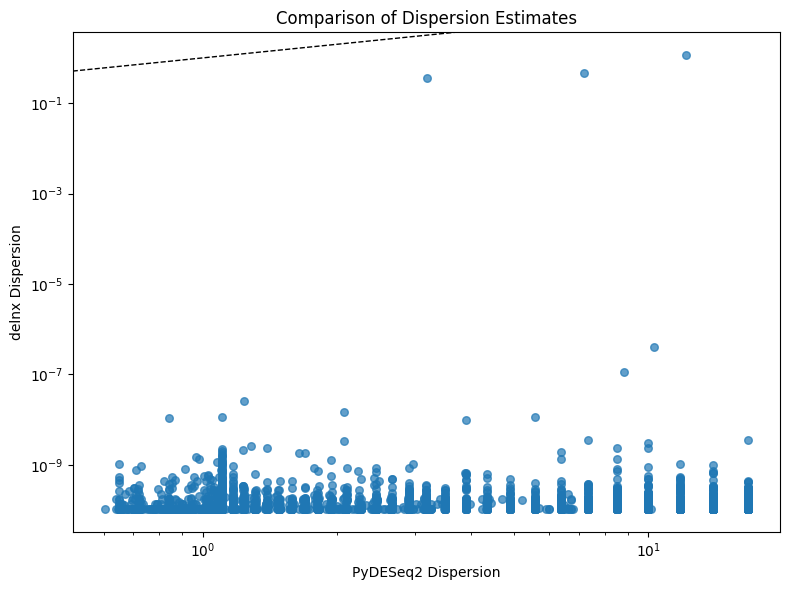

In [4]:
plt.figure(figsize=(8, 6))
plt.scatter(
    dds_icpt.var["MAP_dispersions"],
    adata.var["delnx_dispersions"],
    s=30,
    alpha=0.7,
)
plt.axline((0, 0), slope=1, color="black", linestyle="--", linewidth=1, label="y=x")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("PyDESeq2 Dispersion")
plt.ylabel("delnx Dispersion")
plt.title("Comparison of Dispersion Estimates")
plt.tight_layout()
plt.show()
plt.close()

While not exactly the same, we can see that the dispersion estimates from delnx are very similar to the ones from DESeq2. Now, we can test for differential expression using the fitted model.

In [5]:
# Test for differential expression
de_results = dx.tl.nb_test(adata, fit, contrast="GLI3_KO[T.False]")

print(de_results)

       feature    log2fc      coef       stat      pval  padj
0       NKX2-1 -8.103226 -5.616728  12.595398  0.000404   1.0
1        SFTA3 -8.264163 -5.728281   9.793341  0.001801   1.0
2         LHX8 -7.432299 -5.151677   6.751905  0.009499   1.0
3      NEUROD6  7.950968  5.511191   4.765013  0.029270   1.0
4          PTN  1.130485  0.783593   4.733403  0.029810   1.0
...        ...       ...       ...        ...       ...   ...
16194     GJB3       NaN       NaN        NaN       NaN   1.0
16195    CCL16       NaN       NaN        NaN       NaN   1.0
16196     CCR1       NaN       NaN        NaN       NaN   1.0
16197    PLET1       NaN       NaN        NaN       NaN   1.0
16198     ORM2       NaN       NaN        NaN       NaN   1.0

[16199 rows x 6 columns]


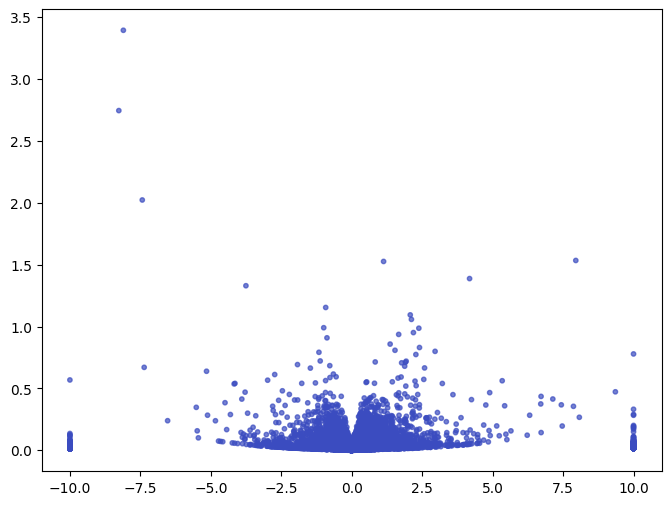

In [6]:
# Vulcano plot
plt.figure(figsize=(8, 6))
plt.scatter(
    de_results["log2fc"],
    -np.log10(de_results["pval"]),
    c=de_results["padj"] < 0.05,
    cmap="coolwarm",
    s=10,
    alpha=0.7,
)